In [87]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# --- paths (notebook in notebooks/ -> repo root is ..) ---
repo_root = Path("..").resolve()
data_dir = repo_root / "data"
figs_dir = repo_root / "figs"
figs_dir.mkdir(exist_ok=True)

# --- requested color palette ---
COL_EXACT     = "#ed1717"   # analytics, exact (red)
COL_GEOM      = "#0295FF"   # analytics, geometric (light blue)
COL_PROJ      = "#ffb000"   # analytics, projection (yellow)

def fmt_float(x: float) -> str:
    """Match your filename convention: 3.0->'3.0', 0.05->'0.05'."""
    if float(x).is_integer():
        return f"{x:.1f}"
    return f"{x:.8g}"

def load_xy(path: Path):
    """Load 2-column .dat with '#' comments: returns (theta, pdf)."""
    theta, pdf = np.loadtxt(path, comments="#", unpack=True)
    return theta, pdf


In [88]:
def plot_compare_pdf(ax, *, Dr: float, dt: float,
                     # axis settings
                     xlim=(0.0, 1.0),
                     # line widths (override per figure if you want)
                     lw_exact=7.0, lw_geom=3.0, lw_proj=2.0,
                     # marker thinning + size
                     step_proj=2, step_geom=2, ms_proj=4.8, ms_geom=4,
                     # switch warnings if geom LAMMPS files are missing
                     warn_missing_geom=True):
    """
    Plot one comparison on a *given* axis:
      - analytic exact/geom/proj (lines)
      - LAMMPS projection/geometric (markers)
    x-axis is theta/pi.
    """

    Dr_str = fmt_float(Dr)
    dt_str = fmt_float(dt)

    # --- file paths (must match your produced filenames) ---
    fa_exact = data_dir / f"pdf_analyt_exact_Dr{Dr_str}_dt{dt_str}.dat"
    fa_geom  = data_dir / f"pdf_analyt_geom_Dr{Dr_str}_dt{dt_str}.dat"
    fa_proj  = data_dir / f"pdf_analyt_proj_Dr{Dr_str}_dt{dt_str}.dat"

    fl_proj  = data_dir / f"pdf_lammps_proj_Dr{Dr_str}_dt{dt_str}.dat"
    fl_geom  = data_dir / f"pdf_lammps_geom_Dr{Dr_str}_dt{dt_str}.dat"  # may not exist yet

    # --- analytic curves (lines) ---
    th, p = load_xy(fa_exact); ax.plot(th/np.pi, p, color=COL_EXACT, lw=lw_exact, label="Analytic, exact")
    th, p = load_xy(fa_geom);  ax.plot(th/np.pi, p, color=COL_GEOM,  lw=lw_geom,  label="Analytic, geometric")
    th, p = load_xy(fa_proj);  ax.plot(th/np.pi, p, color=COL_PROJ,  lw=lw_proj,  label="Analytic, projection")

    # --- LAMMPS projection (markers) ---
    th, p = load_xy(fl_proj)
    x = th/np.pi
    ax.plot(x[::step_proj],
            p[::step_proj],
            linestyle="none",
            marker="o",
            #fillstyle="none",
            markersize=ms_proj,
            markeredgewidth=0.5,
            #color=COL_PROJ_MARK,
            color="black",
            markerfacecolor=COL_PROJ,
            label="LAMMPS, projection")

    # --- LAMMPS geometric (markers; optional file) ---
    if fl_geom.is_file():
        th, p = load_xy(fl_geom)
        x = th/np.pi
        ax.plot(x[::step_geom],
                p[::step_geom],
                linestyle="none",
                marker="s",
                #fillstyle="none",
                markersize=ms_geom,
                markeredgewidth=0.5,
                #color=COL_GEOM_MARK,
                color="black",
                markerfacecolor=COL_GEOM,                
                label="LAMMPS, geometric")
    else:
        if warn_missing_geom:
            print("Missing:", fl_geom)

    # --- axes & legend (common defaults; customize after calling if needed) ---
    ax.set_xlabel(r"$\theta/\pi$")
    ax.set_ylabel(r"$P(\theta; \Delta t)$")
    ax.set_xlim(*xlim)
    ax.legend(frameon=False)


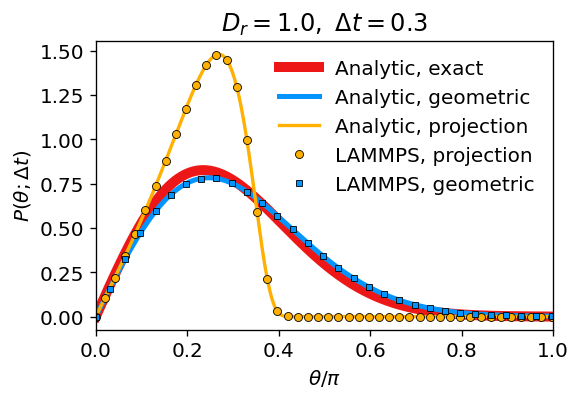

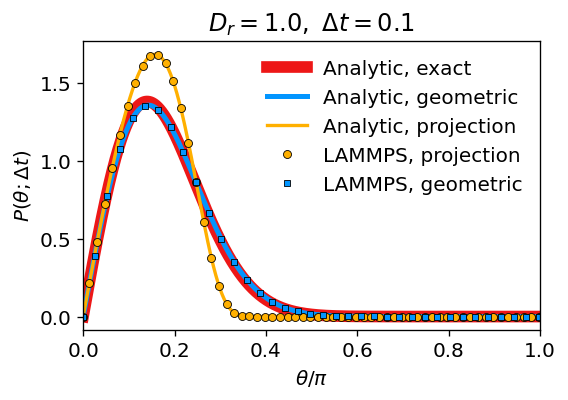

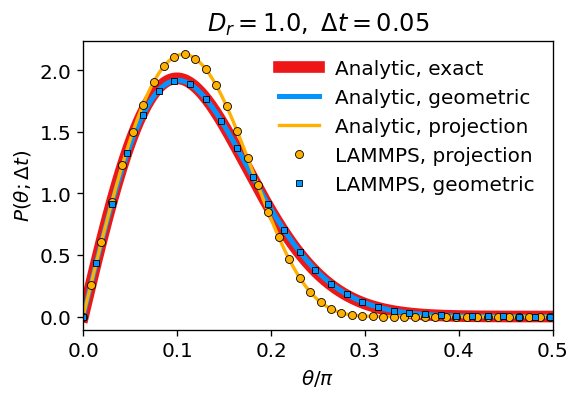

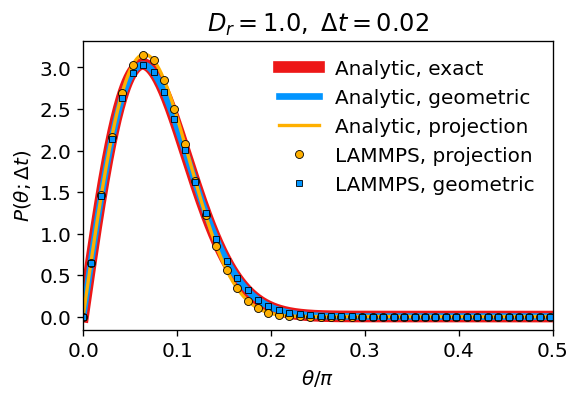

In [89]:
Dr = 1.0

# --- dt = 0.3 : full range ---
fig, ax = plt.subplots(figsize=(5, 3.5))
plot_compare_pdf(ax, Dr=Dr, dt=0.3, xlim=(0,1), step_proj=4, step_geom=6, lw_exact=6.0)
ax.set_title(r"$D_r=1.0,\ \Delta t=0.3$")
fig.tight_layout()
fig.savefig(figs_dir / "pdf_Dr1.0_dt0.3_comparison.png", dpi=300, bbox_inches="tight")
fig.savefig(figs_dir / "pdf_Dr1.0_dt0.3_comparison.pdf", bbox_inches="tight")
plt.show()

# --- dt = 0.1 : full range ---
fig, ax = plt.subplots(figsize=(5, 3.5))
plot_compare_pdf(ax, Dr=Dr, dt=0.1, xlim=(0,1), step_proj=3, step_geom=5)
ax.set_title(r"$D_r=1.0,\ \Delta t=0.1$")
fig.tight_layout()
fig.savefig(figs_dir / "pdf_Dr1.0_dt0.1_comparison.png", dpi=300, bbox_inches="tight")
fig.savefig(figs_dir / "pdf_Dr1.0_dt0.1_comparison.pdf", bbox_inches="tight")
plt.show()

# --- dt = 0.05 : zoom to theta/pi in [0, 0.5] ---
fig, ax = plt.subplots(figsize=(5, 3.5))
plot_compare_pdf(ax, Dr=Dr, dt=0.05, xlim=(0,0.5), step_proj=2, step_geom=3)
ax.set_title(r"$D_r=1.0,\ \Delta t=0.05$")
fig.tight_layout()
fig.savefig(figs_dir / "pdf_Dr1.0_dt0.05_comparison_zoom.png", dpi=300, bbox_inches="tight")
fig.savefig(figs_dir / "pdf_Dr1.0_dt0.05_comparison_zoom.pdf", bbox_inches="tight")
plt.show()

# --- dt = 0.02 : zoom ---
fig, ax = plt.subplots(figsize=(5, 3.5))
plot_compare_pdf(ax, Dr=Dr, dt=0.02, xlim=(0,0.5), step_proj=2, step_geom=2, lw_geom=4.0)
ax.set_title(r"$D_r=1.0,\ \Delta t=0.02$")
fig.tight_layout()
fig.savefig(figs_dir / "pdf_Dr1.0_dt0.02_comparison_zoom.png", dpi=300, bbox_inches="tight")
fig.savefig(figs_dir / "pdf_Dr1.0_dt0.02_comparison_zoom.pdf", bbox_inches="tight")
plt.show()
